Para este trabajo semanal se sintetizaron cinco señales distintas. Para cada funcion se calculo la FFT y se grafico el modulo de la transformada de Fourier (normalizado para 1W de potencia como la referencia para 0db) en funcion de la frecuencia.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

def graficar_par(x1, y1, x2, y2, color1):   #funcion para graficar
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
    
    ax1.plot(x1, y1, color=color1)
    ax1.set_title("Señal")
    ax1.set_xlabel("Muestras")
    ax1.set_ylabel("Amplitud [V]")
    ax1.grid(True)
    
    ax2.plot(x2, y2, color=color1)
    ax2.set_title("Espectro")
    ax2.set_xlabel("Frecuencia")
    ax2.set_ylabel("Amplitud [dB]")
    ax2.grid(True)
    ax2.set_xticks([2000,6000,10000,14000,18000])
    
    plt.tight_layout()
    plt.show()

fs = 40000  # f de muestreo
N = 1000    # muestras


vmax = np.sqrt(2)           # amplitud máxima
dc = 0                      # valor de continua
ff = 2000                   # frecuencia de la señal
ph = 0                      # fase
nn = np.arange(0,N)         # vector de muestras


tt = nn                        #tt era =nn/fs pero lo deje asi para mostrar todo en funcion de las muestras
frec= np.arange(N//2) * fs/N   #vector frecuencia

La primera señal es una funcion senoidal de 2kHz de 1W de potencia media. En el grafico del espectro se ve una delta en clara con maximo en 0dB que corresponde a la frecuencia fundamental de la señal y un piso de ruido en los -300dB aproximadamente. Este ruido es producto del redondeo ya que la computadora no puede almacenar infinitos decimales.

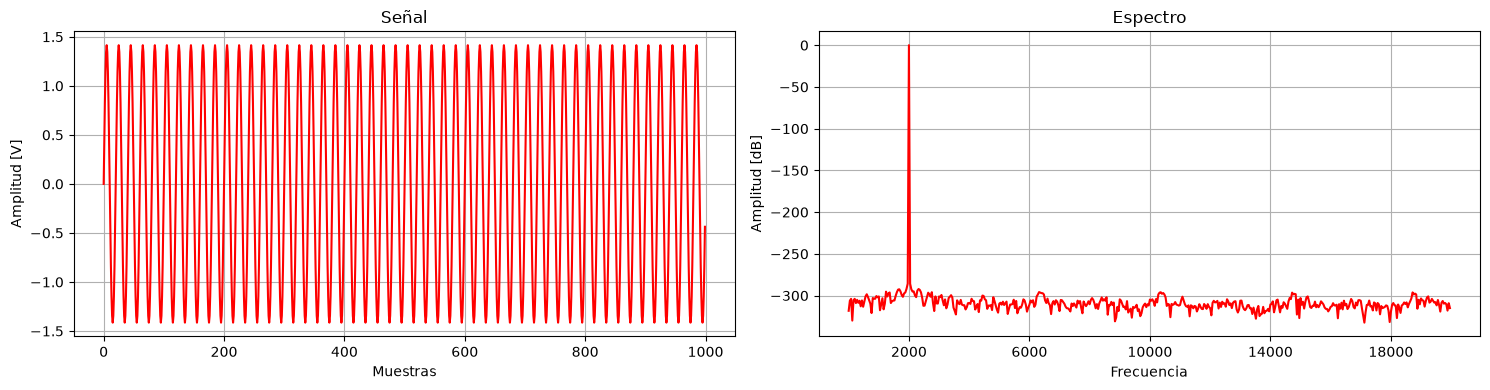

In [2]:
xx1 =   vmax * np.sin(2*np.pi* ff*nn/fs + ph)                   # sinusoidal de 2kHz y 1W
xx1tr = (1/N) * np.fft.fft(xx1)
xx1tr_db = 10 * np.log10(2*(np.abs(xx1tr[:N//2]) ) ** 2)

graficar_par(tt, xx1, frec, xx1tr_db, color1="red")

Esta segunda señal, tambien sinusoidal, tiene la misma frecuencia que la anterior pero el doble de la potencia (2W) y un desfasaje de pi/2. En su grafico del espectro podemos ver que el máximo de la delta está en los 3dB debido a que tiene el doble de potencia que la referencia de 1W. El piso de ruido esta aproximadamente la misma amplitud de -300dB y tiene la misma causa que el de la señal anteior. Como es de esperarse, la fase no afecta en modulo a la señal.

valor maximo de amplitud = 3.0102999566398108


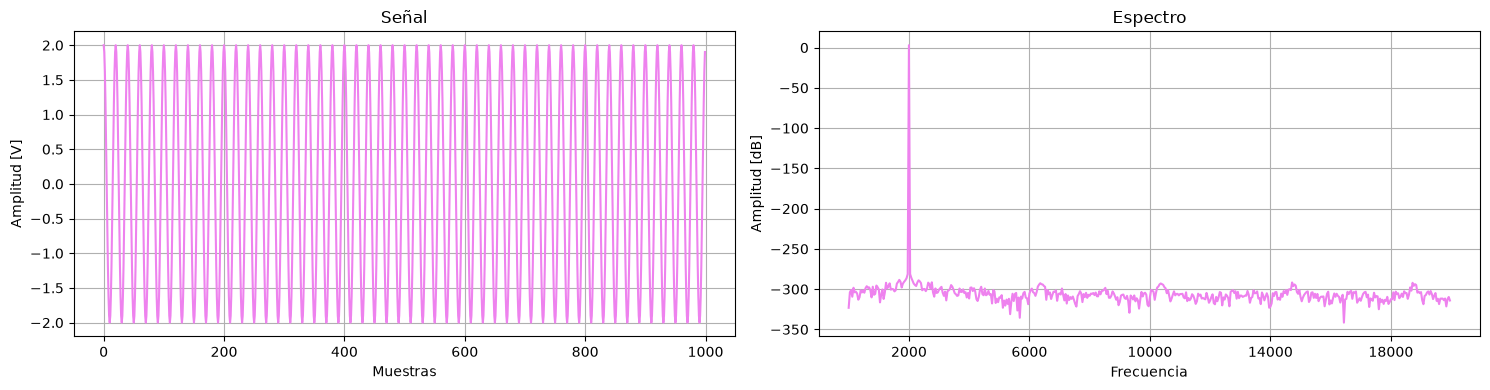

In [3]:
xx2 =      2 * np.sin(2*np.pi* ff*nn/fs + np.pi/2)              # sinusoidal de 2kHz, 2W potencia media y desfasada pi/2 
xx2tr = (1/N) * np.fft.fft(xx2)
xx2tr_db = 10 * np.log10(2*(np.abs(xx2tr[:N//2]) ) ** 2)
amp_max_xx2tr_db=np.max(xx2tr_db)
print(f"valor maximo de amplitud = {amp_max_xx2tr_db}")

graficar_par(tt, xx2, frec, xx2tr_db, color1="violet")

La tercera señal sintetizada es un pulso rectangular de 2kHz, de actividad del 50% y de 1W de potencia. El grafico del espectro muestra maximos claros en los multiplos impares de la frecuencia funamental, armonicos que componen una señal cuadrada. Para que la señal sea perfectamente cuadrada deberia tener infinitos armonicos impares pero por la arquitectura del sistema esto no es posible de obtener. Esta es una de las causas del piso de ruido en aproximadamente -45dB. Este piso de ruido 255dB mayor que en las señales senoidales se debe tambien a la filtracion espectral de la energia de los armonicos hacia las frecuencia vecinas.

valor maximo de amplitud = -0.9367510777488801


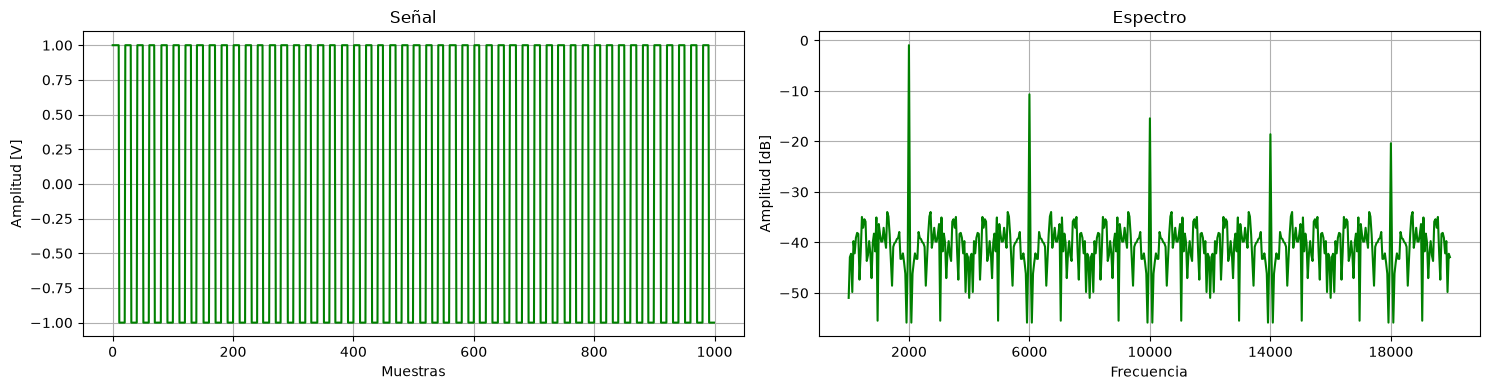

In [4]:
xx3 =      1 * sp.signal.square(2*np.pi*ff*nn/fs)               #pulso rectangular de 2kHz y 1W potencia media
xx3tr = (1/N) * np.fft.fft(xx3) 
xx3tr_db = 10 * np.log10(2*(np.abs(xx3tr[:N//2]) ) ** 2)
amp_max_xx3tr_db=np.max(xx3tr_db)
print(f"valor maximo de amplitud = {amp_max_xx3tr_db}")

graficar_par(tt, xx3, frec, xx3tr_db, color1="green")

Las siguientes señales son ambas de ruido aleatorio con la misma potencia media. La primera fue generada con distribucion normal y la segunda con distribucion uniforme. La diferencia mas clara entre estas señales es la amplitud que prensentan en funcion del tiempo. 

valor medio de amplitud de ruido normal = -39.7055469637962


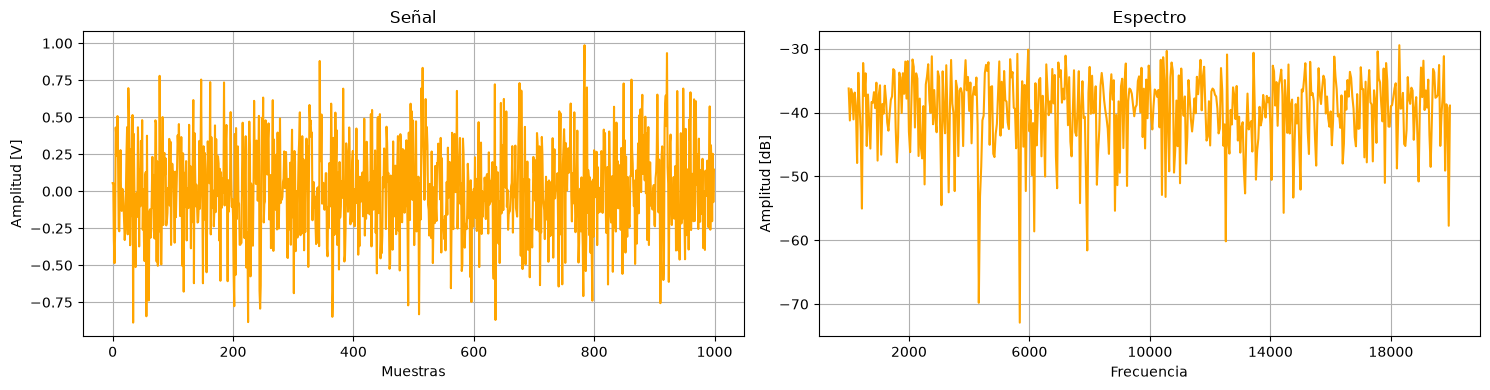

In [5]:
rrn = np.random.normal(0 , 1/np.sqrt(10) , N)                   #ruido ~N, valor medio 0V y var 0.1W
rrntr = (1/N) * np.fft.fft(rrn)
rrntr_db = 10 * np.log10(2*(np.abs(rrntr[:N//2]) ) ** 2)

mediana_rrndb = np.mean(rrntr_db)
print(f"valor medio de amplitud de ruido normal = {mediana_rrndb }")

graficar_par(tt, rrn, frec, rrntr_db, color1="orange")

La señal con distribucion normal tiene maximos de amplitud impredecibles mientras que la señal con distribucion uniforme tiene estos maximos limitados. En los graficos de espctro se observa que ambas señales tiene niveles máximos similares alrededor de los -30dB. Tambien se observa que el valor medio de amplitud en dB es muy similar. 

valor medio de amplitud de ruido uniforme = -39.58895603861684


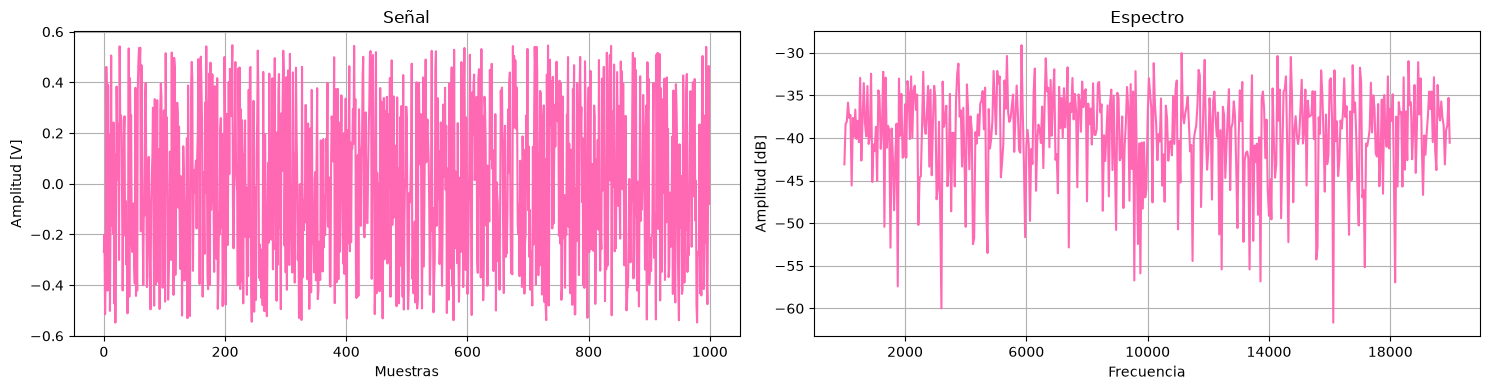

In [6]:
rru = np.random.uniform(-np.sqrt(1.2)/2 , np.sqrt(1.2)/2 , N)   #ruido ~U, valor medio 0V y var 0.1W
rrutr = (1/N) * np.fft.fft(rru)
rrutr_db = 10 * np.log10(2*(np.abs(rrutr[:N//2]) ) ** 2)

mediana_rrudb = np.mean(rrutr_db)
print(f"valor medio de amplitud de ruido uniforme = {mediana_rrudb }")

graficar_par(tt, rru, frec, rrutr_db, color1="hotpink")

A modo de cierre podemos mencionar varias observaciones. Empezando por comprar el ruido de ambas señales senoidales, vimos que el dumplicar la potencia en la frecuencia fundamental no alteró la potencia del piso de ruido de las señales. En cambio, comparando las señales senoidales con la de forma cuadrada, la potencia del piso de ruido aumento al agregar mas informacion en la señal.
Por otro lado, en las señales de ruido, si bien la potencia media de ambas señales es la misma, la de distribucion normal podria causar saturacion en la entrada de un ADC si no se cuenta con una buena SNR debido a la imprevisibilidad de sus maximos de amplitud. En cambio, el ruido uniforme al tenes maximos y minimos limitados, si se conocen estos parametros la saturacion del sistema puede evitarse. 